# (03) contrast play

host: ```yoru```, device: ```cuda:0```

**motivation:** <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_RetinaV1'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Model with warmup

Less sparse, but higher R^2

In [3]:
a = 'Kyoto16-bw_m(g0+logi,p1)_t(16+64×(1,1))_b(128,32)_k(128,512)'
b = 'debug-fisher-xi_b200-ep800-lr(0.002)_temp(0.01:0.5)_gr(1000)_(2025_04_22,22:37)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

800

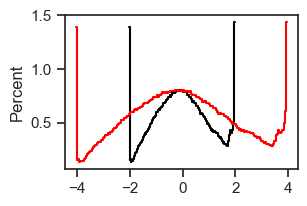

(tensor(1.0040, device='cuda:1'), tensor(2.0081, device='cuda:1'))

In [4]:
data_standard = tr.dl_vld.dataset.tensors[0]
data_high_contrast = data_standard * 2

histplot(data_standard.ravel(), stat='percent', color='k')
histplot(data_high_contrast.ravel(), stat='percent', color='r')
plt.show()

torch.std(data_standard), torch.std(data_high_contrast)

In [5]:
kws_dl = dict(
    batch_size=200,
    drop_last=False,
    shuffle=False,
)
dl_high_contrast = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(data_high_contrast),
    **kws_dl,
)

In [6]:
kws = dict(save_freq=10, n_data_batches=2, data_batch_sz=5000)

output = tr.xtract_ftr('vld', **kws)
output_hc = tr.xtract_ftr(dl_high_contrast, **kws)

100%|███████████████████████████████████| 2/2 [00:23<00:00, 11.71s/it]


In [7]:
quantile_qs = [0.9, 0.95, 0.99, 0.999, 1.0]
for t_idx, actual_time in enumerate(output['times']):
    if actual_time not in [1, 10, 100, 1000]:
        continue

    spks = output['p1']['samples'][:, t_idx]
    spks_hc = output_hc['p1']['samples'][:, t_idx]
    
    quantiles = {f"q = {q}": np.quantile(spks, q) for q in quantile_qs}
    quantiles_hc = {f"q = {q}": np.quantile(spks_hc, q) for q in quantile_qs}
    
    print(f"time: {actual_time}\nquantiles: {quantiles}\nquantiles_hc: {quantiles_hc}\n")

time: 1
quantiles: {'q = 0.9': 4.0, 'q = 0.95': 4.0, 'q = 0.99': 6.0, 'q = 0.999': 9.0, 'q = 1.0': 27.0}
quantiles_hc: {'q = 0.9': 4.0, 'q = 0.95': 5.0, 'q = 0.99': 6.0, 'q = 0.999': 13.0, 'q = 1.0': 63.0}

time: 10
quantiles: {'q = 0.9': 4.0, 'q = 0.95': 6.0, 'q = 0.99': 11.0, 'q = 0.999': 35.0, 'q = 1.0': 167.0}
quantiles_hc: {'q = 0.9': 6.0, 'q = 0.95': 10.0, 'q = 0.99': 33.0, 'q = 0.999': 123.0, 'q = 1.0': 535.0}

time: 100
quantiles: {'q = 0.9': 4.0, 'q = 0.95': 7.0, 'q = 0.99': 15.0, 'q = 0.999': 30.0, 'q = 1.0': 100.0}
quantiles_hc: {'q = 0.9': 10.0, 'q = 0.95': 17.0, 'q = 0.99': 37.0, 'q = 0.999': 110.0, 'q = 1.0': 580.0}

time: 1000
quantiles: {'q = 0.9': 3.0, 'q = 0.95': 7.0, 'q = 0.99': 16.0, 'q = 0.999': 33.0, 'q = 1.0': 124.0}
quantiles_hc: {'q = 0.9': 10.0, 'q = 0.95': 17.0, 'q = 0.99': 39.0, 'q = 0.999': 116.0, 'q = 1.0': 541.0}

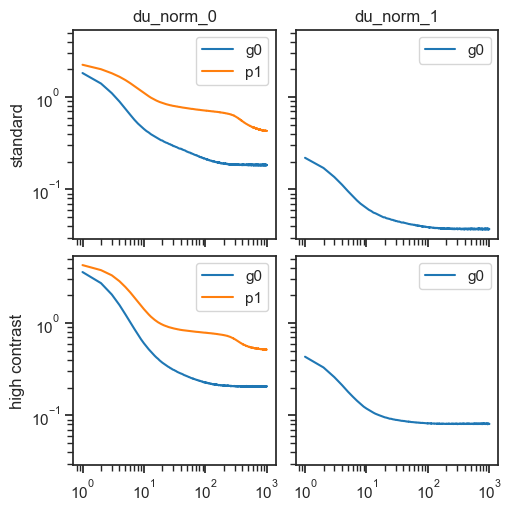

In [8]:
fig, axes = create_figure(2, 2, (5, 5), sharey='all', sharex='all')

axes[0, 0].plot(range(1, 1001), output['g0']['du_norm_0'], color='C0', label='g0')
axes[0, 0].plot(range(1, 1001), output['p1']['du_norm_0'], color='C1', label='p1')
axes[0, 1].plot(range(1, 1001), output['g0']['du_norm_1'], color='C0', label='g0')

axes[1, 0].plot(range(1, 1001), output_hc['g0']['du_norm_0'], color='C0', label='g0')
axes[1, 0].plot(range(1, 1001), output_hc['p1']['du_norm_0'], color='C1', label='p1')
axes[1, 1].plot(range(1, 1001), output_hc['g0']['du_norm_1'], color='C0', label='g0')

for ax in axes.flat:
    ax.set(xscale='log', yscale='log')
for i in range(2):
    axes[0, i].set(title=f"du_norm_{i}")
    axes[i, 0].set(ylabel='standard' if i == 0 else 'high contrast')
add_legend(axes)
plt.show()

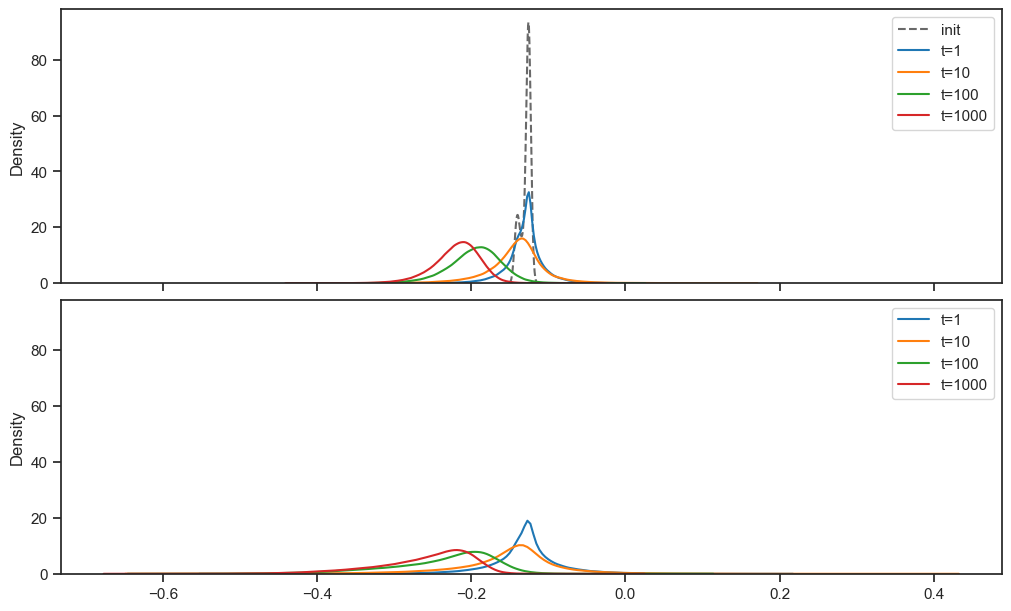

In [10]:
fig, axes = create_figure(2, 1, (10, 6), sharex='all', sharey='all')


u1_init = tonp(tr.model.layers['g0'].u_init[1].squeeze())
sns.kdeplot(u1_init, label='init', color='dimgrey', ls='--', ax=axes[0])

num_samples = 2000

for t_idx, actual_time in enumerate(output['times']):
    if actual_time not in [1, 10, 100, 1000]:
        continue
    x2p = output['g0']['state_1'][:num_samples, t_idx].ravel()
    sns.kdeplot(x2p, label=f't={actual_time}', ax=axes[0])

    x2p = output_hc['g0']['state_1'][:num_samples, t_idx].ravel()
    sns.kdeplot(x2p, label=f't={actual_time}', ax=axes[1])

    # sns.histplot(x2p, label=f't={actual_time}', element='step', fill=False, stat='percent', ax=ax)

add_legend(axes)
plt.show()

In [11]:
sigma_first = np.exp(output['g0']['state_1'][:, 0].ravel())
sigma_last = np.exp(output['g0']['state_1'][:, -1].ravel())
sigma_first.mean(), sigma_last.mean()

(0.8780664, 0.80353564)

In [12]:
sigma_first = np.exp(output_hc['g0']['state_1'][:, 0].ravel())
sigma_last = np.exp(output_hc['g0']['state_1'][:, -1].ravel())
sigma_first.mean(), sigma_last.mean()

(0.8788261, 0.77276546)

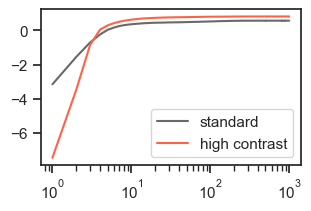

In [13]:
fig, ax = create_figure()
ax.plot(range(1, 1001), output['p1']['r2'], label='standard', color='dimgrey')
ax.plot(range(1, 1001), output_hc['p1']['r2'], label='high contrast', color='tomato')
add_legend(ax)
ax.set(xscale='log')
plt.show()

In [28]:
output['p1']['r2'][-1], output_hc['p1']['r2'][-1]

(0.56997395, 0.8110417)

In [14]:
for t_idx, actual_time in enumerate(output['times']):
    if actual_time not in [1, 10, 100, 1000]:
        continue
    spks = output['p1']['samples'][:, t_idx]
    spks_hc = output_hc['p1']['samples'][:, t_idx]
    
    life, pop, portions = sparse_score(spks, cutoff=0.01)
    life_hc, pop_hc, portions_hc = sparse_score(spks_hc, cutoff=0.01)

    msg = '\n'.join([
        f"time: {actual_time}",
        f"lifetime: {life.mean().item():0.3f}",
        f"lifetime_hc: {life_hc.mean().item():0.3f}",
        f"portions:{portions}",
        f"portions_hc:{portions_hc}\n",
    ])
    print(msg)

time: 1
lifetime: 0.358
lifetime_hc: 0.369
portions:{'0': 16.7, '1': 28.7, '2': 25.8, '3': 16.1, '4': 7.8, '5': 3.2, '6': 1.1, '7': 0.4, '8+': 0.3}
portions_hc:{'0': 17.0, '1': 28.3, '2': 25.3, '3': 16.0, '4': 7.9, '5': 3.3, '6': 1.3, '7': 0.4, '8+': 0.4}

time: 10
lifetime: 0.541
lifetime_hc: 0.760
portions:{'0': 22.4, '1': 27.6, '2': 21.4, '3': 13.0, '4': 7.0, '5': 3.5, '6': 1.8, '7': 1.0, '8': 0.6, '9+': 1.7}
portions_hc:{'0': 25.4, '1': 24.0, '2': 17.4, '3': 11.0, '4': 6.6, '5': 3.9, '6': 2.5, '7': 1.7, '8': 1.2, '9': 
0.9, '10+': 5.5}

time: 100
lifetime: 0.810
lifetime_hc: 0.829
portions:{'0': 53.1, '1': 21.7, '2': 9.4, '3': 4.7, '4': 2.8, '5': 1.8, '6': 1.3, '7': 1.0, '8': 0.8, '9+': 3.4}
portions_hc:{'0': 51.2, '1': 15.5, '2': 7.4, '3': 4.4, '4': 3.1, '5': 2.4, '6': 1.9, '7': 1.6, '8': 1.3, '9': 1.1, 
'10': 1.0, '11+': 9.1}

time: 1000
lifetime: 0.899
lifetime_hc: 0.861
portions:{'0': 80.2, '1': 4.5, '2': 3.0, '3': 2.3, '4': 1.8, '5': 1.5, '6': 1.2, '7': 0.9, '8+': 4.6}
portions_hc:{'0': 70.6, '1': 4.0, '2': 3.0, '3': 2.5, '4': 2.1, '5': 1.9, '6': 1.6, '7': 1.4, '8': 1.3, '9': 1.1, 
'10': 1.0, '11+': 9.5}

In [15]:
sigma_final = np.exp(output['g0']['state_1'][:, -1])
sigma_final_hc = np.exp(output_hc['g0']['state_1'][:, -1])

sigma_final.shape, sigma_final_hc.shape

((9821, 128), (9821, 128))

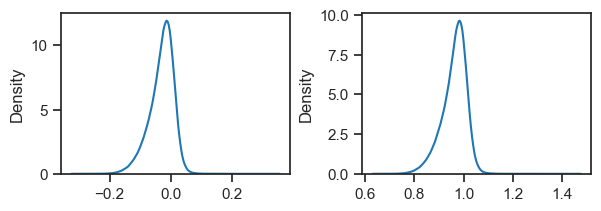

In [16]:
delta = sigma_final_hc - sigma_final
ratio = sigma_final_hc / sigma_final

fig, axes = create_figure(1, 2)
sns.kdeplot(delta.ravel(), ax=axes[0])
sns.kdeplot(ratio.ravel(), ax=axes[1])
plt.show()

In [17]:
delta.mean(), ratio.mean()

(-0.03077026, 0.9616556)

In [18]:
posterior_mu = output['g0']['state_0'][:, -1].copy()
posterior_xi = output['g0']['state_1'][:, -1].copy()
posterior_mu_hc = output_hc['g0']['state_0'][:, -1].copy()
posterior_xi_hc = output_hc['g0']['state_1'][:, -1].copy()

In [19]:
def gaussian_pdf(mu, sigma):
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
    y = sp_stats.norm.pdf(x, mu, sigma)
    return x, y

In [20]:
true = tr.dl_vld.dataset.tensors[0].flatten(start_dim=1)
var = tonp(torch.var(true, dim=1))
order_samples = np.argsort(var)[::-1]

In [21]:
sample_i = order_samples[50]
sample_i

2081

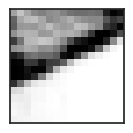

In [22]:
x = tonp(tr.dl_vld.dataset.tensors[0][sample_i].squeeze())

fig, ax = create_figure(1, 1, (1.22,) * 2)
imshow(x, cmap='Greys')
remove_ticks(ax, False)
plt.show()

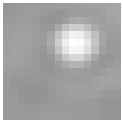

In [23]:
neuron_i = 83   # 66

tr.model.show(order=[neuron_i], method='abs-max', dpi=30);

In [24]:
mu = posterior_mu[sample_i, neuron_i]
sigma = np.exp(posterior_xi[sample_i, neuron_i])
mu_hc = posterior_mu_hc[sample_i, neuron_i]
sigma_hc = np.exp(posterior_xi_hc[sample_i, neuron_i])

(mu, sigma), (mu_hc, sigma_hc)

((1.8876828, 0.8056896), (2.2336085, 0.7020511))

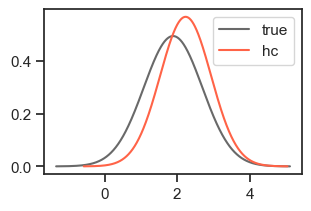

In [25]:
fig, ax = create_figure()
ax.plot(*gaussian_pdf(mu, sigma), color='dimgrey', label='true')
ax.plot(*gaussian_pdf(mu_hc, sigma_hc), color='tomato', label='hc')
add_legend(ax)
plt.show()

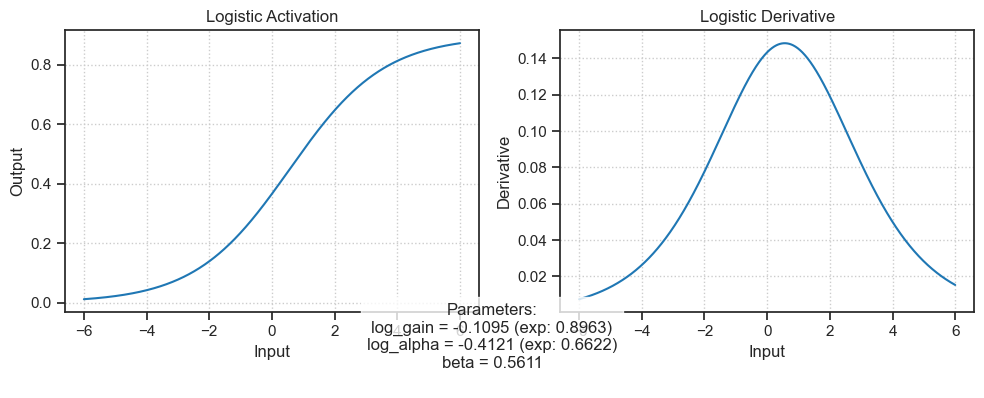

In [26]:
fig = tr.model.layers['g0'].activation.show(neuron_i, x_range=(-6, 6))
plt.show()

In [123]:
# g = log_gain
# a = log_alpha
# b = beta

## Model w/o warmup

sparse, but lower R^2

In [29]:
a = 'Kyoto16-bw_m(g0+logi,p1)_t(16×(1,1))_b(8,8)_k(128,512)'
b = 'b200-ep800-lr(0.002)_temp(0.01:0.5)_gr(1000)_(2025_05_02,21:16)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

800

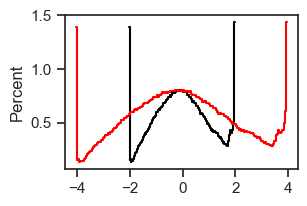

(tensor(1.0040, device='cuda:1'), tensor(2.0081, device='cuda:1'))

In [30]:
data_standard = tr.dl_vld.dataset.tensors[0]
data_high_contrast = data_standard * 2

histplot(data_standard.ravel(), stat='percent', color='k')
histplot(data_high_contrast.ravel(), stat='percent', color='r')
plt.show()

torch.std(data_standard), torch.std(data_high_contrast)

In [31]:
kws_dl = dict(
    batch_size=200,
    drop_last=False,
    shuffle=False,
)
dl_high_contrast = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(data_high_contrast),
    **kws_dl,
)

In [32]:
kws = dict(save_freq=10, n_data_batches=2, data_batch_sz=5000)

output = tr.xtract_ftr('vld', **kws)
output_hc = tr.xtract_ftr(dl_high_contrast, **kws)

100%|███████████████████████████████████| 2/2 [00:23<00:00, 12.00s/it]


In [33]:
quantile_qs = [0.9, 0.95, 0.99, 0.999, 1.0]

for t_idx, actual_time in enumerate(output['times']):
    if actual_time not in [1, 10, 100, 1000]:
        continue

    spks = output['p1']['samples'][:, t_idx]
    spks_hc = output_hc['p1']['samples'][:, t_idx]

    quantiles = {f"q = {q}": np.quantile(spks, q) for q in quantile_qs}
    quantiles_hc = {f"q = {q}": np.quantile(spks_hc, q) for q in quantile_qs}

    print(f"time: {actual_time}\nquantiles: {quantiles}\nquantiles_hc: {quantiles_hc}\n")

time: 1
quantiles: {'q = 0.9': 2.0, 'q = 0.95': 2.0, 'q = 0.99': 3.0, 'q = 0.999': 5.0, 'q = 1.0': 11.0}
quantiles_hc: {'q = 0.9': 2.0, 'q = 0.95': 2.0, 'q = 0.99': 4.0, 'q = 0.999': 8.0, 'q = 1.0': 25.0}

time: 10
quantiles: {'q = 0.9': 1.0, 'q = 0.95': 2.0, 'q = 0.99': 4.0, 'q = 0.999': 9.0, 'q = 1.0': 32.0}
quantiles_hc: {'q = 0.9': 3.0, 'q = 0.95': 6.0, 'q = 0.99': 18.0, 'q = 0.999': 39.0, 'q = 1.0': 172.0}

time: 100
quantiles: {'q = 0.9': 0.0, 'q = 0.95': 1.0, 'q = 0.99': 5.0, 'q = 0.999': 10.0, 'q = 1.0': 40.0}
quantiles_hc: {'q = 0.9': 4.0, 'q = 0.95': 7.0, 'q = 0.99': 19.0, 'q = 0.999': 41.0, 'q = 1.0': 174.0}

time: 1000
quantiles: {'q = 0.9': 0.0, 'q = 0.95': 1.0, 'q = 0.99': 5.0, 'q = 0.999': 10.0, 'q = 1.0': 39.0}
quantiles_hc: {'q = 0.9': 4.0, 'q = 0.95': 8.0, 'q = 0.99': 20.0, 'q = 0.999': 43.0, 'q = 1.0': 19408.0}

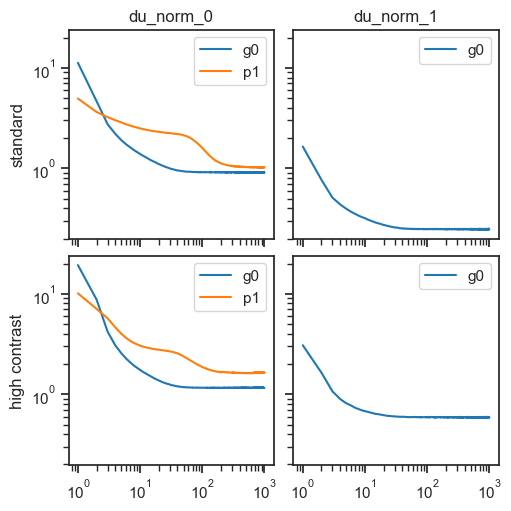

In [34]:
fig, axes = create_figure(2, 2, (5, 5), sharey='all', sharex='all')

axes[0, 0].plot(range(1, 1001), output['g0']['du_norm_0'], color='C0', label='g0')
axes[0, 0].plot(range(1, 1001), output['p1']['du_norm_0'], color='C1', label='p1')
axes[0, 1].plot(range(1, 1001), output['g0']['du_norm_1'], color='C0', label='g0')

axes[1, 0].plot(range(1, 1001), output_hc['g0']['du_norm_0'], color='C0', label='g0')
axes[1, 0].plot(range(1, 1001), output_hc['p1']['du_norm_0'], color='C1', label='p1')
axes[1, 1].plot(range(1, 1001), output_hc['g0']['du_norm_1'], color='C0', label='g0')

for ax in axes.flat:
    ax.set(xscale='log', yscale='log')
for i in range(2):
    axes[0, i].set(title=f"du_norm_{i}")
    axes[i, 0].set(ylabel='standard' if i == 0 else 'high contrast')
add_legend(axes)
plt.show()

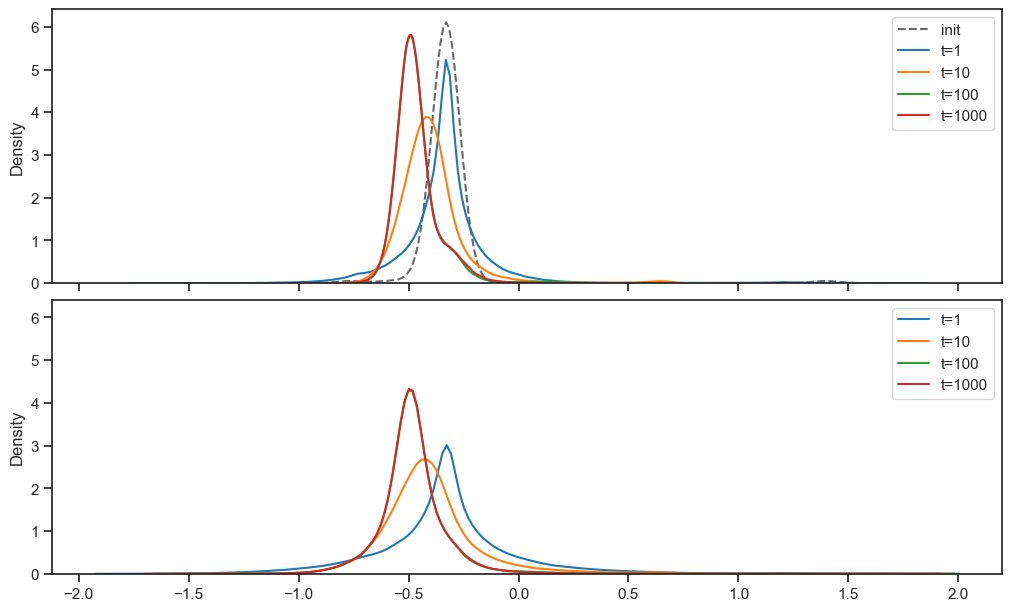

In [35]:
fig, axes = create_figure(2, 1, (10, 6), sharex='all', sharey='all')


u1_init = tonp(tr.model.layers['g0'].u_init[1].squeeze())
sns.kdeplot(u1_init, label='init', color='dimgrey', ls='--', ax=axes[0])

num_samples = 2000

for t_idx, actual_time in enumerate(output['times']):
    if actual_time not in [1, 10, 100, 1000]:
        continue
    x2p = output['g0']['state_1'][:num_samples, t_idx].ravel()
    sns.kdeplot(x2p, label=f't={actual_time}', ax=axes[0])

    x2p = output_hc['g0']['state_1'][:num_samples, t_idx].ravel()
    sns.kdeplot(x2p, label=f't={actual_time}', ax=axes[1])

    # sns.histplot(x2p, label=f't={actual_time}', element='step', fill=False, stat='percent', ax=ax)

add_legend(axes)
plt.show()

In [36]:
sigma_first = np.exp(output['g0']['state_1'][:, 0].ravel())
sigma_last = np.exp(output['g0']['state_1'][:, -1].ravel())
sigma_first.mean(), sigma_last.mean()

(0.73805904, 0.6305221)

In [37]:
sigma_first = np.exp(output_hc['g0']['state_1'][:, 0].ravel())
sigma_last = np.exp(output_hc['g0']['state_1'][:, -1].ravel())
sigma_first.mean(), sigma_last.mean()

(0.76746947, 0.6246167)

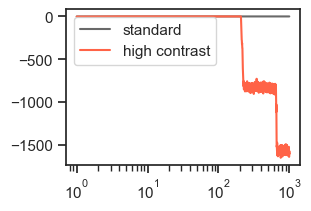

In [38]:
fig, ax = create_figure()
ax.plot(range(1, 1001), output['p1']['r2'], label='standard', color='dimgrey')
ax.plot(range(1, 1001), output_hc['p1']['r2'], label='high contrast', color='tomato')
add_legend(ax)
ax.set(xscale='log')
plt.show()

In [39]:
output['p1']['r2'][-1], output_hc['p1']['r2'][-1]

(0.24428608, -1586.9897)

In [40]:
output['p1']['r2'][100], output_hc['p1']['r2'][100]

(0.24727748, 0.5874909)

In [41]:
for t_idx, actual_time in enumerate(output['times']):
    if actual_time not in [1, 10, 100, 1000]:
        continue
    spks = output['p1']['samples'][:, t_idx]
    spks_hc = output_hc['p1']['samples'][:, t_idx]
    
    life, pop, portions = sparse_score(spks, cutoff=0.01)
    life_hc, pop_hc, portions_hc = sparse_score(spks_hc, cutoff=0.01)

    msg = '\n'.join([
        f"time: {actual_time}",
        f"lifetime: {life.mean().item():0.3f}",
        f"lifetime_hc: {life_hc.mean().item():0.3f}",
        f"portions:{portions}",
        f"portions_hc:{portions_hc}\n",
    ])
    print(msg)

time: 1
lifetime: 0.698
lifetime_hc: 0.712
portions:{'0': 63.9, '1': 26.0, '2': 7.3, '3': 2.0, '4': 0.6, '5+': 0.2}
portions_hc:{'0': 63.3, '1': 24.9, '2': 7.4, '3': 2.5, '4': 1.0, '5+': 0.9}

time: 10
lifetime: 0.818
lifetime_hc: 0.869
portions:{'0': 72.1, '1': 19.8, '2': 5.1, '3': 1.6, '4': 0.7, '5+': 0.7}
portions_hc:{'0': 66.3, '1': 16.3, '2': 5.9, '3': 2.9, '4': 1.7, '5': 1.2, '6': 0.9, '7+': 4.8}

time: 100
lifetime: 0.948
lifetime_hc: 0.887
portions:{'0': 90.7, '1': 4.7, '2': 1.9, '3': 1.0, '4': 0.6, '5+': 1.0}
portions_hc:{'0': 77.6, '1': 6.0, '2': 3.5, '3': 2.5, '4': 1.9, '5': 1.5, '6': 1.1, '7': 0.9, '8+': 5.0}

time: 1000
lifetime: 0.953
lifetime_hc: 0.988
portions:{'0': 92.2, '1': 3.2, '2': 1.8, '3': 1.1, '4': 0.6, '5+': 1.1}
portions_hc:{'0': 79.7, '1': 4.3, '2': 3.2, '3': 2.4, '4': 1.8, '5': 1.4, '6': 1.1, '7': 0.9, '8+': 5.1}

In [42]:
sigma_final = np.exp(output['g0']['state_1'][:, -1])
sigma_final_hc = np.exp(output_hc['g0']['state_1'][:, -1])

sigma_final.shape, sigma_final_hc.shape

((9821, 128), (9821, 128))

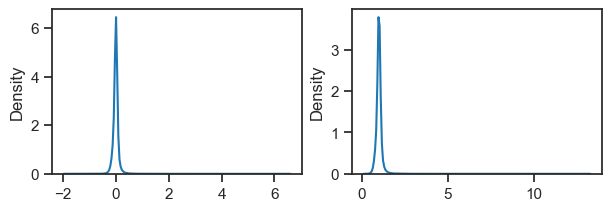

In [43]:
delta = sigma_final_hc - sigma_final
ratio = sigma_final_hc / sigma_final

fig, axes = create_figure(1, 2)
sns.kdeplot(delta.ravel(), ax=axes[0])
sns.kdeplot(ratio.ravel(), ax=axes[1])
plt.show()

In [44]:
delta.mean(), ratio.mean()

(-0.005905243, 0.995492)

In [45]:
posterior_mu = output['g0']['state_0'][:, -1].copy()
posterior_xi = output['g0']['state_1'][:, -1].copy()
posterior_mu_hc = output_hc['g0']['state_0'][:, -1].copy()
posterior_xi_hc = output_hc['g0']['state_1'][:, -1].copy()

In [46]:
def gaussian_pdf(mu, sigma):
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
    y = sp_stats.norm.pdf(x, mu, sigma)
    return x, y

In [47]:
true = tr.dl_vld.dataset.tensors[0].flatten(start_dim=1)
var = tonp(torch.var(true, dim=1))
order_samples = np.argsort(var)[::-1]

In [48]:
sample_i = order_samples[50]
sample_i

2081

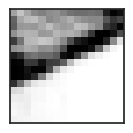

In [49]:
x = tonp(tr.dl_vld.dataset.tensors[0][sample_i].squeeze())

fig, ax = create_figure(1, 1, (1.22,) * 2)
imshow(x, cmap='Greys')
remove_ticks(ax, False)
plt.show()

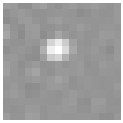

In [85]:
neuron_i = 64   # 66

tr.model.show(order=[neuron_i], method='abs-max', dpi=30);

In [86]:
mu = posterior_mu[sample_i, neuron_i]
sigma = np.exp(posterior_xi[sample_i, neuron_i])
mu_hc = posterior_mu_hc[sample_i, neuron_i]
sigma_hc = np.exp(posterior_xi_hc[sample_i, neuron_i])

(mu, sigma), (mu_hc, sigma_hc)

((3.3483214, 0.60855), (4.0044537, 0.61255246))

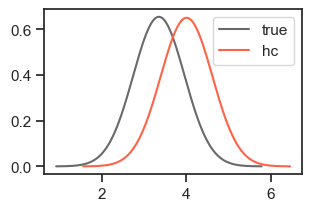

In [87]:
fig, ax = create_figure()
ax.plot(*gaussian_pdf(mu, sigma), color='dimgrey', label='true')
ax.plot(*gaussian_pdf(mu_hc, sigma_hc), color='tomato', label='hc')
add_legend(ax)
plt.show()

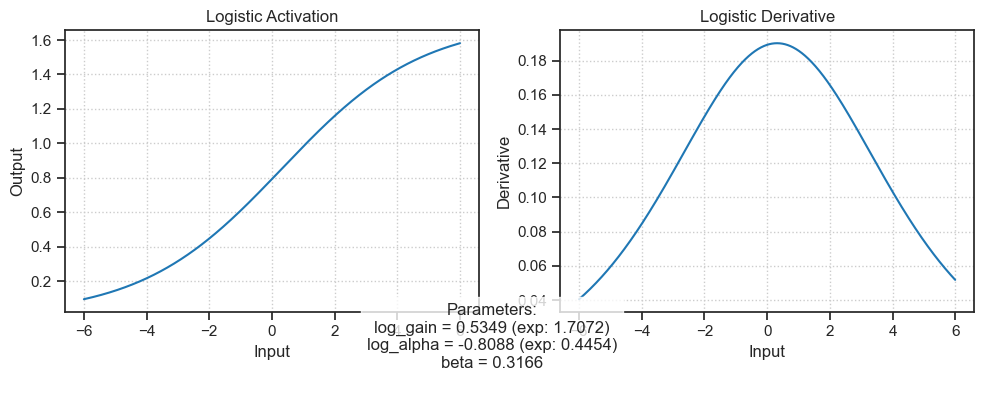

In [88]:
fig = tr.model.layers['g0'].activation.show(neuron_i, x_range=(-6, 6))
plt.show()